# Project 1: GP Operational Analysis

## Healthcare Analytics Portfolio

An operational analysis of NHS General Practice appointment activity in Hertfordshire & West Essex using publicly available NHS England data.

## Portfolio Context

This notebook forms the first project within a broader Healthcare Analytics Portfolio built using NHS primary care appointment data.

The portfolio aims to explore different aspects of healthcare service delivery and operational performance through six interconnected projects:

1. GP Operational Analysis
2. DNA (Did Not Attend) Analysis
3. Workforce Utilisation Analysis
4. Demand Forecasting
5. Regional Benchmarking
6. Power BI Dashboard Development

This project establishes a baseline understanding of GP appointment activity and provides the foundation for subsequent analyses..

## Executive Summary

This project analyses GP appointment activity across Hertfordshire & West Essex using publicly available NHS England appointment data.

The analysis investigates service delivery methods, workforce utilisation, patient access patterns, appointment outcomes and temporal demand trends.

Key findings indicate that face-to-face consultations remain the dominant appointment mode, while telephone consultations continue to account for a substantial proportion of activity. Other practice staff deliver appointment volumes approaching those managed by GPs, highlighting the increasing importance of multidisciplinary care teams within primary care services.

Approximately 45% of appointments occurred on the same day they were booked, suggesting sustained reactive demand. Appointment activity also demonstrated recurring seasonal variation, with demand peaks in autumn and winter.

Overall, the findings suggest that primary care services continue to operate under sustained demand pressure while increasingly relying on multidisciplinary workforce models and hybrid consultation methods to support service delivery.

## Introduction

Primary care services play a critical role within the NHS, acting as the first point of contact for patients seeking healthcare support.

Understanding operational patterns in appointment activity is important for evaluating healthcare demand, workforce utilisation, patient access and service efficiency.

This project analyses publicly available NHS England General Practice appointment data for Hertfordshire & West Essex. The aim is to establish a baseline understanding of appointment activity by examining how services are delivered, who delivers care, how quickly patients access appointments and how demand changes over time.

The findings generated here will inform subsequent portfolio projects investigating appointment non-attendance, workforce utilisation, demand forecasting, regional benchmarking and dashboard development.

## Research Questions

This project seeks to answer the following questions:

1. How are GP appointments being delivered?
2. Who is delivering appointments across primary care services?
3. How quickly are patients accessing appointments?
4. What happens to scheduled appointments?
5. How does appointment activity change over time?
6. How does same-day appointment demand fluctuate over time?

## Methodology

### Data Source

The dataset used in this project was obtained from the NHS England Appointments in General Practice publication.

### Study Region

This analysis focuses on Hertfordshire & West Essex.

### Analytical Approach

The analysis uses descriptive and exploratory analytical techniques to examine patterns in service delivery, workforce utilisation, appointment access and temporal demand.

### Tools Used

- Python
- pandas
- NumPy
- matplotlib
- Jupyter Notebook

## Data Loading and Inspection

Before conducting the analysis, the dataset was loaded and inspected to understand its structure, variables and data quality.

The dataset contains aggregated appointment activity information, including consultation mode, healthcare professional type, appointment outcomes, waiting times and appointment volumes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Regional_CSV_HertfordshireWEssex.csv")
df.head()

,SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_ONS_CODE,SUB_ICB_LOCATION_NAME,ICB_ONS_CODE,ICB_NAME,REGION_ONS_CODE,REGION_NAME,APPOINTMENT_MONTH,APPT_STATUS,HCP_TYPE,APPT_MODE,TIME_BETWEEN_BOOK_AND_APPT,COUNT_OF_APPOINTMENTS
0,06K,E38000049,NHS Hertfordshire and West Essex ICB - 06K,E54000025,NHS Hertfordshire and West Essex Integrated Ca...,E40000007,East of England,OCT2023,Attended,GP,Face-to-Face,1 Day,6219
1,06K,E38000049,NHS Hertfordshire and West Essex ICB - 06K,E54000025,NHS Hertfordshire and West Essex Integrated Ca...,E40000007,East of England,OCT2023,Attended,GP,Face-to-Face,15 to 21 Days,5323
2,06K,E38000049,NHS Hertfordshire and West Essex ICB - 06K,E54000025,NHS Hertfordshire and West Essex Integrated Ca...,E40000007,East of England,OCT2023,Attended,GP,Face-to-Face,2 to 7 Days,13785
3,06K,E38000049,NHS Hertfordshire and West Essex ICB - 06K,E54000025,NHS Hertfordshire and West Essex Integrated Ca...,E40000007,East of England,OCT2023,Attended,GP,Face-to-Face,22 to 28 Days,3065
4,06K,E38000049,NHS Hertfordshire and West Essex ICB - 06K,E54000025,NHS Hertfordshire and West Essex Integrated Ca...,E40000007,East of England,OCT2023,Attended,GP,Face-to-Face,8 to 14 Days,8267


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20044 entries, 0 to 20043
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   SUB_ICB_LOCATION_CODE       20044 non-null  object
 1   SUB_ICB_LOCATION_ONS_CODE   20044 non-null  object
 2   SUB_ICB_LOCATION_NAME       20044 non-null  object
 3   ICB_ONS_CODE                20044 non-null  object
 4   ICB_NAME                    20044 non-null  object
 5   REGION_ONS_CODE             20044 non-null  object
 6   REGION_NAME                 20044 non-null  object
 7   APPOINTMENT_MONTH           20044 non-null  object
 8   APPT_STATUS                 20044 non-null  object
 9   HCP_TYPE                    20044 non-null  object
 10  APPT_MODE                   20044 non-null  object
 11  TIME_BETWEEN_BOOK_AND_APPT  20044 non-null  object
 12  COUNT_OF_APPOINTMENTS       20044 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 2.0+ MB


## Appointment Modes

### Research Question

How are GP appointments being delivered across primary care services?

Understanding consultation modes provides insight into service delivery patterns and the extent to which primary care relies on face-to-face, telephone, online and home-visit consultations.

This section explores the distribution of appointment activity across consultation modes to better understand how primary care services are being delivered within Hertfordshire & West Essex.


In [5]:
mode_counts = df.groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"].sum()

In [6]:
mode_counts.sort_values(ascending=False)

APPT_MODE
Face-to-Face    14464244
Telephone        5116714
Video/Online     1146854
Unknown           660028
Home Visit        180998
Name: COUNT_OF_APPOINTMENTS, dtype: int64

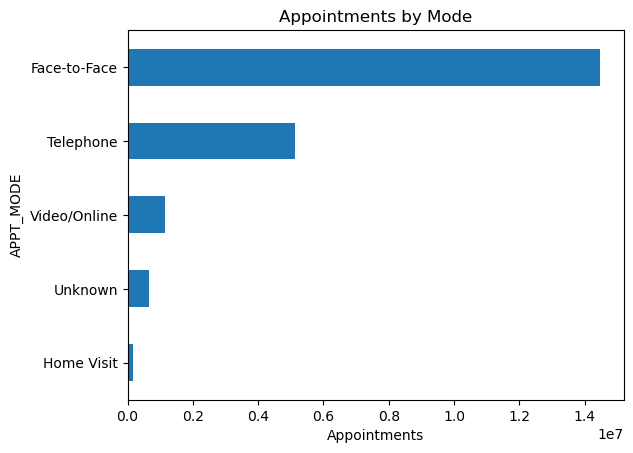

In [7]:
mode_counts.sort_values().plot(kind="barh")

plt.xlabel("Appointments")
plt.title("Appointments by Mode")

plt.show()

### Interpretation

Face-to-face consultations remained the dominant mode of GP service delivery throughout the study period. Telephone consultations also accounted for a substantial proportion of activity, indicating continued reliance on hybrid consultation models within primary care services.

The findings suggest that while digital and remote consultation methods remain important components of service delivery, face-to-face care continues to form the foundation of primary care activity within Hertfordshire & West Essex.

## Workforce Utilisation

### Research Question

Who is delivering appointments across primary care services?

Understanding workforce utilisation is important for evaluating how healthcare demand is distributed across different professional groups. In recent years, NHS primary care services have increasingly relied on multidisciplinary workforce models to support service delivery.

This section examines appointment activity by healthcare professional type to understand the relative contribution of GPs and other practice staff.

In [8]:
hcp_counts = df.groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"].sum()
hcp_counts.sort_values(ascending=False)

HCP_TYPE
GP                      11151727
Other Practice staff     9923554
Unknown                   493557
Name: COUNT_OF_APPOINTMENTS, dtype: int64

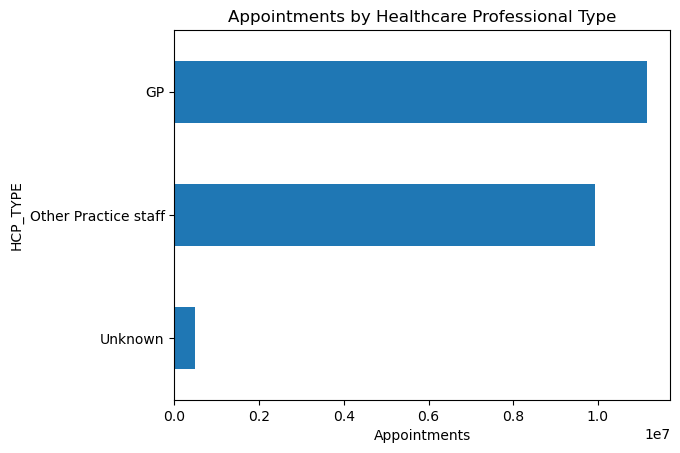

In [9]:
hcp_counts.sort_values().plot(kind="barh")

plt.xlabel("Appointments")
plt.title("Appointments by Healthcare Professional Type")

plt.show()

### Interpretation

GPs delivered the largest proportion of appointments throughout the study period. However, other practice staff also accounted for a substantial volume of activity, reflecting the growing importance of multidisciplinary care teams within primary care services.

The relatively narrow gap between GP and non-GP appointment volumes suggests that primary care services increasingly rely on a broader clinical workforce to manage demand and maintain service capacity.

## Access to Care

### Research Question

How quickly are patients accessing appointments?

Timely access to primary care services is an important indicator of healthcare system performance. Understanding the time between appointment booking and appointment delivery provides insight into patient access, service responsiveness and operational demand pressures.

This section examines the distribution of waiting times between booking and appointment delivery to better understand access patterns within primary care services.

In [11]:
wait_times = df.groupby("TIME_BETWEEN_BOOK_AND_APPT")["COUNT_OF_APPOINTMENTS"].sum()
wait_times.sort_values(ascending=False)

TIME_BETWEEN_BOOK_AND_APPT
Same Day                  9738254
2 to 7 Days               3652592
8  to 14 Days             2739187
15  to 21 Days            1681130
1 Day                     1492472
More than 28 Days         1130229
22  to 28 Days            1123198
Unknown / Data Quality      11776
Name: COUNT_OF_APPOINTMENTS, dtype: int64

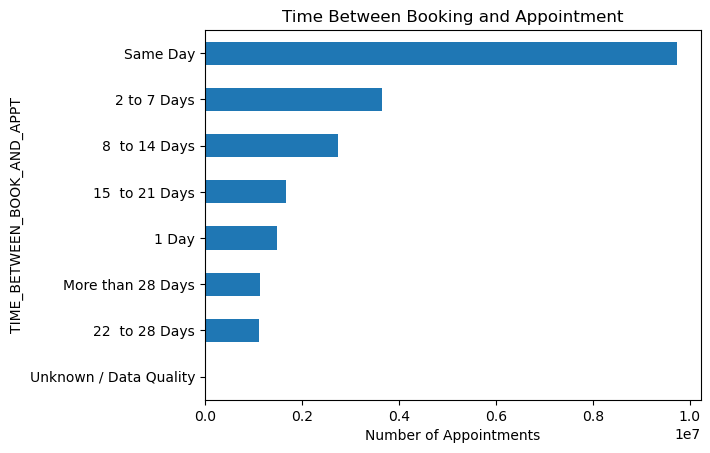

In [12]:
wait_times.sort_values().plot(kind="barh")

plt.xlabel("Number of Appointments")
plt.title("Time Between Booking and Appointment")

plt.show()

In [13]:
total_appointments = df["COUNT_OF_APPOINTMENTS"].sum()

same_day = wait_times["Same Day"]

same_day_percentage = (same_day / total_appointments) * 100

same_day_percentage

np.float64(45.14964598463765)

In [14]:
round(same_day_percentage, 2)

np.float64(45.15)

### Interpretation

Approximately 45% of appointments occurred on the same day they were booked, making same-day access the most common appointment pathway within the dataset.

This finding suggests that primary care services are managing substantial levels of reactive demand and may operate under sustained short-term capacity pressures. The dominance of same-day appointments highlights the importance of maintaining flexible appointment capacity to support urgent and unplanned healthcare needs.

## Appointment Outcomes

### Research Question

What happens to scheduled appointments?

Appointment outcomes provide insight into service utilisation, operational efficiency and potential capacity loss. Understanding attendance patterns is important for evaluating whether appointment capacity is being used effectively and identifying opportunities to improve service efficiency.

This section examines appointment attendance and non-attendance patterns across the study period.

In [15]:
status_counts = df.groupby("APPT_STATUS")["COUNT_OF_APPOINTMENTS"].sum()

status_counts.sort_values(ascending=False)

APPT_STATUS
Attended    19402463
Unknown      1378848
DNA           787527
Name: COUNT_OF_APPOINTMENTS, dtype: int64

### Initial Findings

Most appointments were successfully attended. However, approximately 788,000 appointments were recorded as Did Not Attend (DNA), representing a substantial volume of potentially unused clinical capacity.

Although attendance rates remain high overall, missed appointments can contribute to operational inefficiencies and reduce the availability of appointment capacity within primary care services.

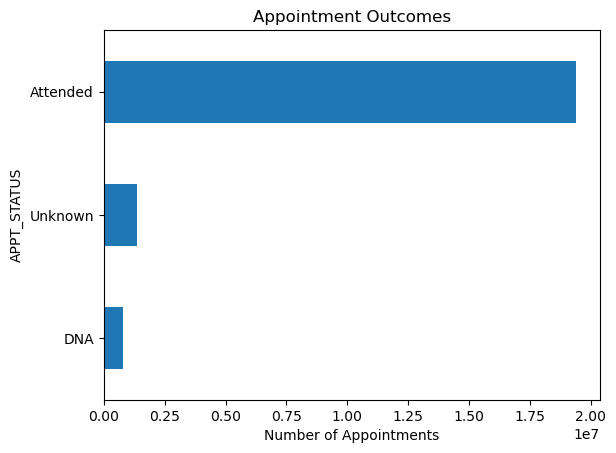

In [16]:
status_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Appointments")
plt.title("Appointment Outcomes")

plt.show()

In [17]:
dna = status_counts["DNA"]

dna_percentage = (dna / total_appointments) * 100

round(dna_percentage, 2)

np.float64(3.65)

### Interpretation

Approximately 3.65% of appointments resulted in non-attendance (DNA). While proportionally small, this represents a substantial number of missed appointments across the study period.

Reducing non-attendance rates could improve appointment utilisation and increase effective clinical capacity without requiring additional workforce or appointment slots.

## Temporal Trends in Appointment Activity

### Research Question

How does GP appointment activity change over time?

Examining appointment activity over time helps identify seasonal patterns, fluctuations in healthcare demand and periods of increased operational pressure.

This section explores monthly appointment volumes to understand how demand for primary care services changes throughout the study period.

In [18]:
monthly_trend = df.groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"].sum()

monthly_trend

APPOINTMENT_MONTH
APR2024    699106
APR2025    667740
AUG2024    630598
AUG2025    623868
DEC2023    601442
DEC2024    660818
DEC2025    707395
FEB2024    714993
FEB2025    691785
FEB2026    712942
JAN2024    755634
JAN2025    776818
JAN2026    758864
JUL2024    713998
JUL2025    742971
JUN2024    649996
JUN2025    698227
MAR2024    694391
MAR2025    728723
MAR2026    778521
MAY2024    693503
MAY2025    664888
NOV2023    726686
NOV2024    730270
NOV2025    706708
OCT2023    792567
OCT2024    905822
OCT2025    917131
SEP2024    685845
SEP2025    736588
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [19]:
df["MONTH_DATE"] = pd.to_datetime(df["APPOINTMENT_MONTH"], format="%b%Y")

In [20]:
monthly_trend = df.groupby("MONTH_DATE")["COUNT_OF_APPOINTMENTS"].sum()

monthly_trend

MONTH_DATE
2023-10-01    792567
2023-11-01    726686
2023-12-01    601442
2024-01-01    755634
2024-02-01    714993
2024-03-01    694391
2024-04-01    699106
2024-05-01    693503
2024-06-01    649996
2024-07-01    713998
2024-08-01    630598
2024-09-01    685845
2024-10-01    905822
2024-11-01    730270
2024-12-01    660818
2025-01-01    776818
2025-02-01    691785
2025-03-01    728723
2025-04-01    667740
2025-05-01    664888
2025-06-01    698227
2025-07-01    742971
2025-08-01    623868
2025-09-01    736588
2025-10-01    917131
2025-11-01    706708
2025-12-01    707395
2026-01-01    758864
2026-02-01    712942
2026-03-01    778521
Name: COUNT_OF_APPOINTMENTS, dtype: int64

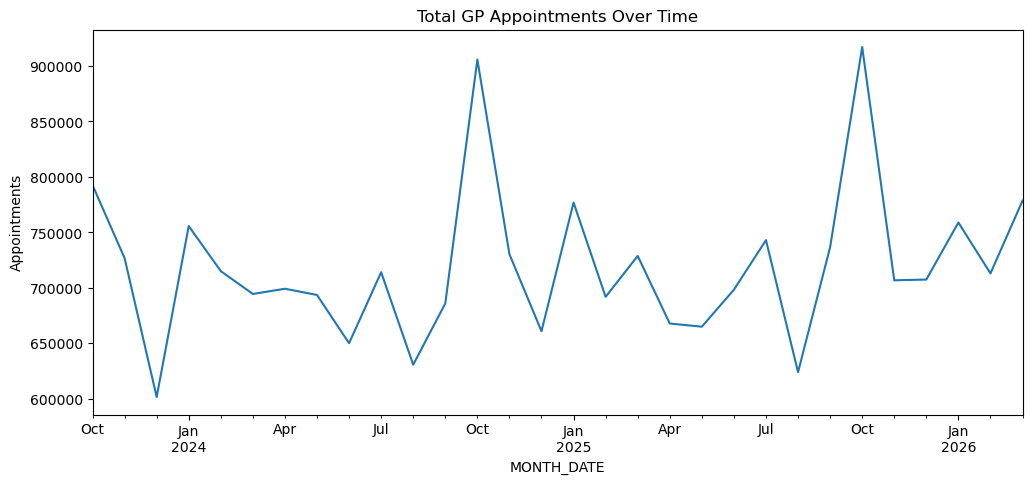

In [21]:
monthly_trend.plot(figsize=(12,5))

plt.ylabel("Appointments")
plt.title("Total GP Appointments Over Time")

plt.show()

### Interpretation

GP appointment activity demonstrated recurring seasonal variation throughout the study period. Appointment volumes consistently peaked during autumn and winter, particularly around October, while lower activity was observed during summer months.

These recurring patterns suggest that primary care services experience predictable fluctuations in demand that may be associated with seasonal healthcare pressures and changing service utilisation patterns.

## Appointment Modes Over Time

### Research Question

How have appointment delivery methods changed over time?

Understanding how consultation modes evolve over time provides insight into changing service delivery practices and the extent to which primary care services rely on face-to-face, telephone and digital consultations.

This section explores temporal trends in appointment delivery methods to identify changes in consultation patterns throughout the study period.

In [22]:
mode_trend = df.groupby(
    ["MONTH_DATE", "APPT_MODE"]
)["COUNT_OF_APPOINTMENTS"].sum().unstack()

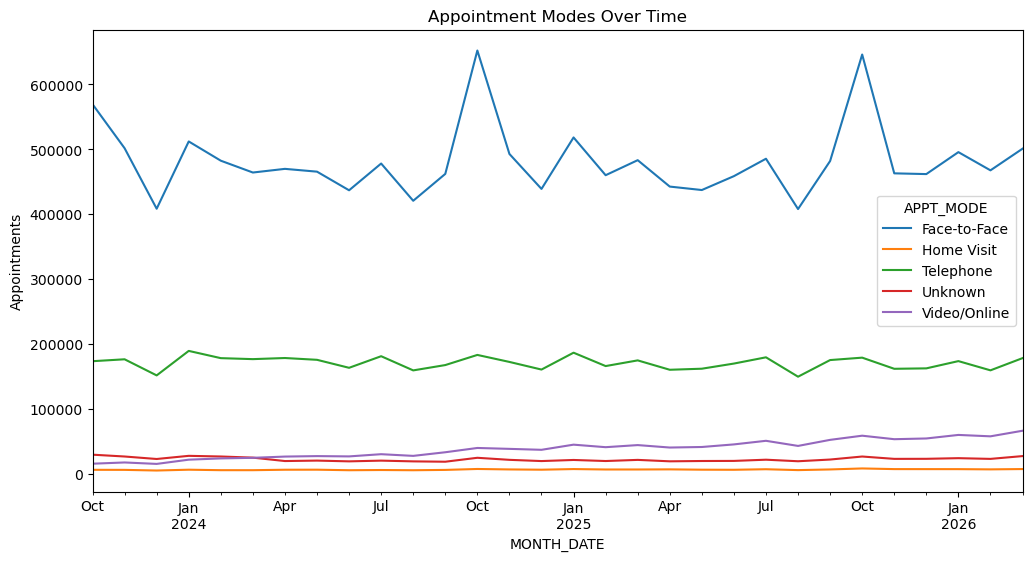

In [25]:
mode_trend.plot(figsize=(12,6))

plt.ylabel("Appointments")
plt.title("Appointment Modes Over Time")

plt.show()

### Interpretation

Face-to-face appointments remained the dominant consultation mode throughout the study period. Telephone consultations also accounted for a substantial proportion of activity and remained relatively stable over time.

Video and online consultations demonstrated a gradual upward trend, suggesting increasing integration of digital consultation methods within primary care services. However, digital consultations remained supplementary to traditional face-to-face care rather than replacing it.

The recurring peaks observed across multiple appointment modes further reinforce the seasonal demand patterns identified earlier in the analysis.

## Workforce Utilisation Over Time

### Research Question

How has appointment workload been distributed across healthcare professional types over time?

Workforce utilisation is a key component of healthcare service delivery. Understanding how appointment activity is distributed between GPs and other practice staff provides insight into workforce capacity, service design and the role of multidisciplinary care teams.

This section examines workforce trends over time to understand how primary care services allocate appointment activity across different professional groups.

In [26]:
hcp_trend = df.groupby(
    ["MONTH_DATE", "HCP_TYPE"]
)["COUNT_OF_APPOINTMENTS"].sum().unstack()

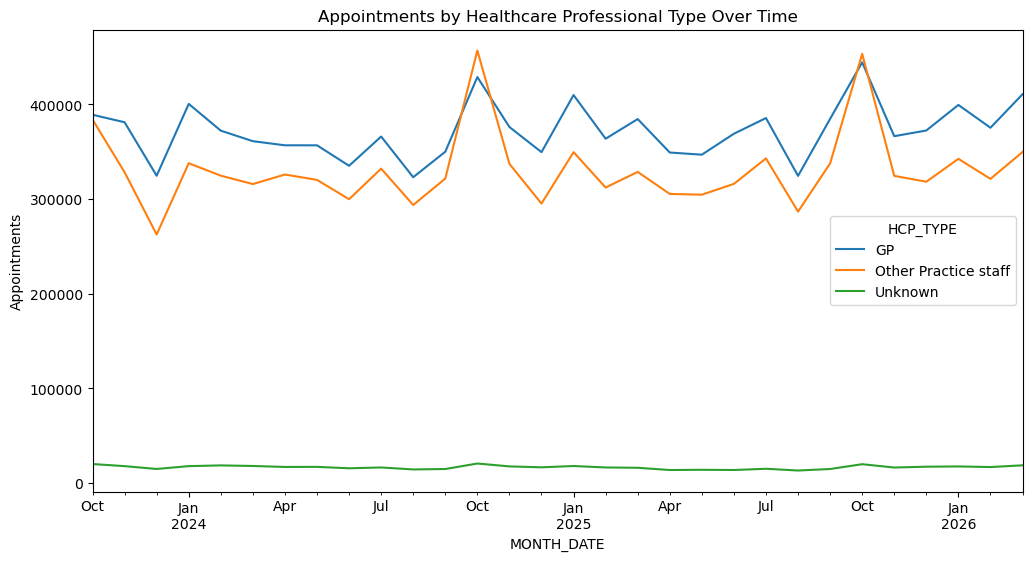

In [28]:
hcp_trend.plot(figsize=(12,6))

plt.ylabel("Appointments")
plt.title("Appointments by Healthcare Professional Type Over Time")

plt.show()

### Interpretation

GPs consistently accounted for the highest appointment volumes throughout the study period. However, other practice staff also delivered a substantial proportion of appointments, highlighting the operational importance of multidisciplinary workforce models within primary care services.

The relatively stable trends observed across both groups suggest that workforce utilisation patterns remained consistent over time. Seasonal increases in appointment activity affected both GPs and other practice staff, indicating that demand pressures are distributed across the wider primary care workforce rather than concentrated solely among GPs.

## Same-Day Demand Over Time

### Research Question

How has same-day appointment demand changed over time?

Same-day appointments are often associated with urgent or reactive healthcare needs. Examining trends in same-day appointment activity provides insight into operational demand pressures and the extent to which primary care services must maintain flexible appointment capacity.

This section investigates how same-day appointment demand fluctuated throughout the study period.

In [29]:
same_day_df = df[
    df["TIME_BETWEEN_BOOK_AND_APPT"] == "Same Day"
]

In [30]:
same_day_trend = same_day_df.groupby(
    "MONTH_DATE"
)["COUNT_OF_APPOINTMENTS"].sum()

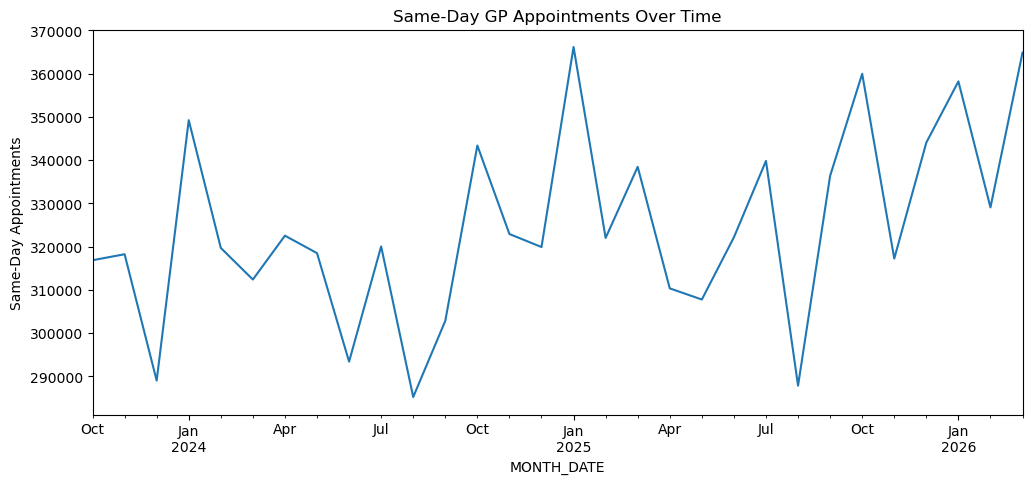

In [31]:
same_day_trend.plot(figsize=(12,5))

plt.ylabel("Same-Day Appointments")
plt.title("Same-Day GP Appointments Over Time")

plt.show()

### Interpretation

Same-day appointment demand remained consistently high throughout the study period, indicating sustained reactive demand within primary care services.

Seasonal increases were evident during autumn and winter, mirroring the broader appointment activity trends identified earlier in the analysis. There was also some indication of gradually increasing same-day demand in later periods, although the overall trend remained relatively stable.

These findings suggest that primary care services continue to operate under ongoing short-term demand pressures and require sufficient capacity to accommodate urgent healthcare needs.

## Key Findings

- Face-to-face consultations remained the dominant appointment mode throughout the study period.
- Telephone consultations continued to play a substantial operational role.
- Other practice staff delivered appointment volumes approaching those managed by GPs.
- Approximately 45% of appointments occurred on the same day they were booked.
- DNA appointments represented approximately 3.65% of total activity.
- Appointment demand demonstrated recurring seasonal variation, with peaks observed during autumn and winter periods.

## Conclusion

This project explored operational patterns in GP appointment activity across Hertfordshire & West Essex using publicly available NHS England appointment data.

The analysis identified several important findings. Face-to-face consultations remained the dominant appointment mode, while telephone consultations continued to play a substantial role in service delivery. Other practice staff delivered appointment volumes approaching those managed by GPs, demonstrating the increasing importance of multidisciplinary workforce models within primary care services.

Approximately 45% of appointments occurred on the same day they were booked, highlighting sustained reactive demand. Although DNA appointments accounted for only 3.65% of total activity, they represented a significant volume of potentially unused clinical capacity. Time-series analysis revealed recurring seasonal variation in appointment activity, with demand peaks consistently observed during autumn and winter periods.

Taken together, these findings suggest that primary care services within Hertfordshire & West Essex continue to operate under sustained demand pressure while increasingly relying on multidisciplinary workforce models and hybrid consultation methods to maintain service delivery. The recurring seasonal patterns observed throughout the analysis highlight the importance of proactive workforce and capacity planning within NHS primary care services.

Limitations

This analysis used aggregated NHS appointment data and therefore could not evaluate:

patient-level characteristics
demographic variation
practice-level differences
causal drivers of demand patterns

Additionally, the analysis focused on descriptive operational trends rather than predictive modelling.

## Future Work

### Potential extensions of this analysis could include:

- practice-level comparisons
- seasonal forecasting
- demographic stratification
- predictive modelling of appointment demand
- analysis of DNA risk factors